# Life expectancy and GDP

This project seeks to analyse how life expectancy is affected by Gross Domestic Product (GDP) across the world.

We will be answering the following research questions:
1. Has life expectancy increased over time globally?
2. Is a higher GDP linked to a higher life expectancy?

In order to do this, we will visualise relevant metrics. If relevant, we will plot regression lines to find a relationship between different metrics. Additionally, we will run a hypothesis text to see if Germans have a higher life expectancy than Americans.

## Data cleaning
First, let's import the data and clean the dataset. The data contains the life expectancy in Chile, China, Germany, Mexico, the US, and Zimbabwe from 2000 to 2015.
To make the columns easier to manipulate let's first renameing the life expectancy column to be something shorter.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

life_exp = pd.read_csv("all_data.csv")
life_exp.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [2]:
# rename long column name
life_exp.rename(columns={"Life expectancy at birth (years)":"Expectancy"}, inplace=True)
life_exp.head()

,Country,Year,Expectancy,GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [3]:
# check the data types are as expected
life_exp.dtypes

Country        object
Year            int64
Expectancy    float64
GDP           float64
dtype: object

These are all appropriate datatypes, since the countries can be considered categories, the year should be an integer, life expectancy should be a decimal number of years, and GDP should be a decimal value.

Let's move on to the analysis of the data.

## Part 1: Life expectancy over time
To see if life expectancy has changed over time, we can plot life expectancy against the year.

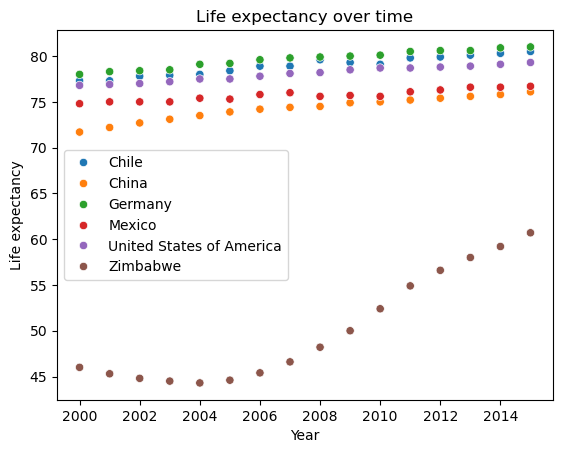

In [4]:
sns.scatterplot(data=life_exp, x='Year', y='Expectancy', hue='Country')
plt.title("Life expectancy over time")
plt.xlabel("Year")
plt.ylabel("Life expectancy")
plt.legend(loc=6)

Here it's clear to see that there has been a slight increase over time. However, it would not make sense to plot a regression curve for all countries in the data, since Zimbabwe is an outlier - having an average life expectancy at least 10 years lower than the other countries. Let's plot a line-of-best-fit for the countries in this dataset.

sns.lmplot(data=life_exp, x="Year", y="Expectancy", hue="Country")
plt.title("Life expectancy over time")
plt.xlabel("Year")
plt.ylabel("Life expectancy")

This confirms that there is a non-linear relationship between year and life expectancy in Zimbabwe, since there is certain amount of error to the regression line. Nonetheless, we see a positiove relationship between the two variables, meaning life expectancy has been increasing over time.

Let's look at the line-of-best-fit for all other countres in the dataset to find a pattern.

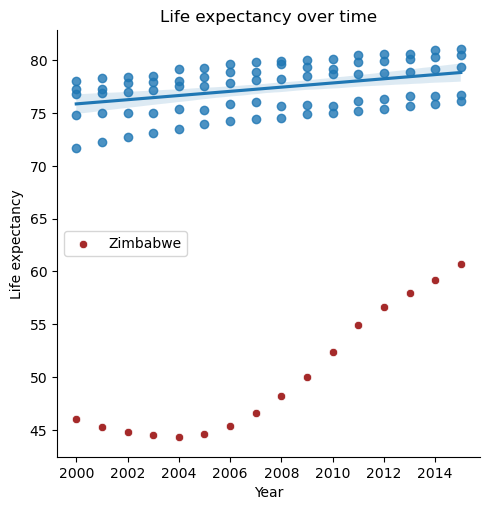

In [5]:
life_exp_no_zim = life_exp[life_exp.Country != "Zimbabwe"]
life_exp_zim = life_exp[life_exp.Country == "Zimbabwe"]

sns.lmplot(data=life_exp_no_zim, x="Year", y="Expectancy")
sns.scatterplot(data=life_exp_zim, x="Year", y="Expectancy", color="brown", label="Zimbabwe")

plt.title("Life expectancy over time")
plt.xlabel("Year")
plt.ylabel("Life expectancy")
plt.legend(loc=6)

In [6]:
# find the equation of the regression line
model = sm.OLS.from_formula("Year ~ Expectancy", data=life_exp_no_zim).fit()
model.params

Intercept     1942.800467
Expectancy       0.836681
dtype: float64

$$ y = m*x + c $$
$$ y = 0.84*x + 1942.80 $$

Here we can see the y-intercept is 1942.80 and the gradient is 0.84. This means that, during the period under investigation, life expectancy has been increasing in these countries on average by 0.84 years each year.

(Note, the y-intercept of 1942 would suggest that there was a 0-year life expectancy in the year 1942. Because this is clearly incorrect, we would expect the underlying relationship to have changed between 1942 and 2000).

## Part 2: Are GDP and life expectancy linked?
To analyse whether GDP and life expectancy are linked let's create a scatter plot and draw a regression line if appropriate.

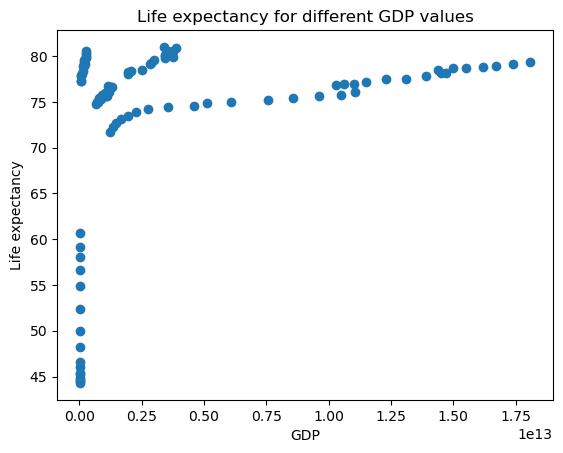

In [7]:
# plot life expectancy against GDP
plt.scatter(life_exp.GDP, life_exp.Expectancy)
plt.title("Life expectancy for different GDP values")
plt.xlabel("GDP")
plt.ylabel("Life expectancy")
plt.show()

Let's remove Zimbabwe from the dataset again, since it is an outlier.

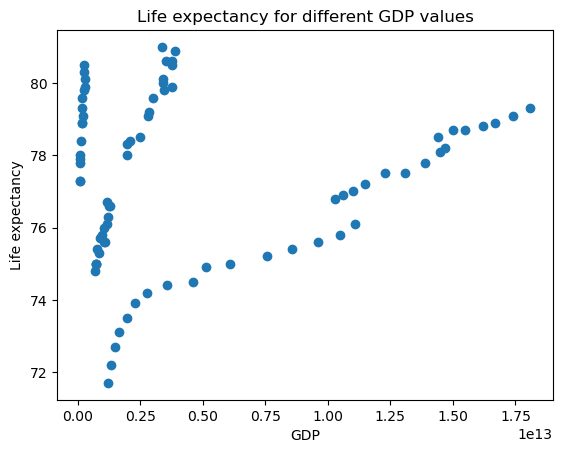

In [8]:
# plot life expectancy against GDP
plt.scatter(life_exp_no_zim.GDP, life_exp_no_zim.Expectancy)
plt.title("Life expectancy for different GDP values")
plt.xlabel("GDP")
plt.ylabel("Life expectancy")
plt.show()

Using one single linear relationship to describe this data may be problematic, so let's plot multiple regression lines instead.

Text(56.757430555555544, 0.5, 'Life expectancy')

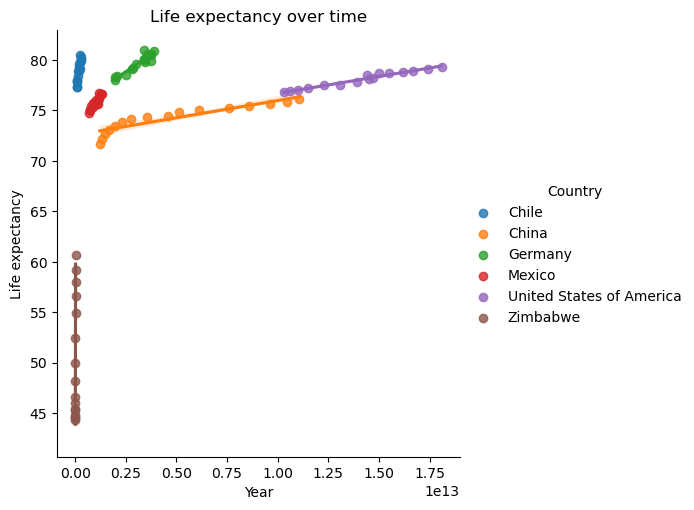

In [9]:
sns.lmplot(data=life_exp, x="GDP", y="Expectancy", hue="Country")
plt.title("Life expectancy over time")
plt.xlabel("Year")
plt.ylabel("Life expectancy")

It may be inaccurate to give one definitive regression line for all these countries. However, it is clear that as GDP increase, so does life expectancy. 

## Conclusion
We found out that life expectancy has indeed been increasing over time and that life expectancy increases with GDP. Life expectancy has been increasing roughly linearly between 2000 and 2015 in Chile, China, Germany, Mexico and the United States, but there seems to be a different underlying relationship in Zimbabwe. We might need to investigate the political situation in Zimbabwe further to understand the reason for this relationship.

## Limitations
It could be useful to add more historical data points to these graphs to see if the linear relationships found hold. This could help us more, and to more accurately plot the regression lines.